# NiSpace workflows

The notebooks so far have built up the NiSpace pipeline step by step — `fit()`, `transform_y()`, `clean_y()`, `colocalize()`, `permute()`, `plot()`. That level of control is great when you need flexibility. But for standard analyses, NiSpace provides **workflow functions** that run the complete pipeline in a single call.

Three workflows are available:

| Function | Question answered | Null model |
|----------|-------------------|------------|
| `simple_colocalization()` | Does this map colocalize with reference maps? | Surrogate map permutation |
| `group_comparison()` | Do brain alterations in this group colocalize with reference maps? | Group label permutation |
| `simple_xsea()` | Is the average colocalization with a set of maps higher than expected by chance? | Surrogate map permutation |

All workflows return a fitted `NiSpace` object. Use the `get_*` methods to retrieve results:

```python
nsp = simple_colocalization(...)
colocs   = nsp.get_colocalizations()
p_values = nsp.get_p_values()
q_values = nsp.get_p_values(mc_method="meff")   # or any other mc_method
```

In [1]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import pandas as pd
import numpy as np

## `simple_colocalization()` — single map

The simplest workflow: you have one (or a few) group-level brain maps and want to test whether they colocalize with a set of reference maps.

INFO | 01/06/26 12:43:23 | nispace.workflows: Loading integrated pet dataset as X data.


INFO | 01/06/26 12:43:23 | nispace.datasets: Loading pet maps.


INFO | 01/06/26 12:43:23 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 01/06/26 12:43:23 | nispace.datasets: Filtering maps by collection.


INFO | 01/06/26 12:43:23 | nispace.datasets: Loading data parcellated with 'Schaefer200Parcels7Networks'


...

Null colocalizations (spearman, 4 proc):   0%|                                                        | 0/1000 [00:00<?, ?it/s]

Null colocalizations (spearman, 4 proc):  50%|██████████████████████▏                     | 504/1000 [00:00<00:00, 4099.86it/s]

Null colocalizations (spearman, 4 proc): 100%|███████████████████████████████████████████| 1000/1000 [00:00<00:00, 6755.48it/s]

INFO | 01/06/26 12:43:34 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'upper'}).


INFO | 01/06/26 12:43:35 | nispace.plotting: Significance annotation: 2/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


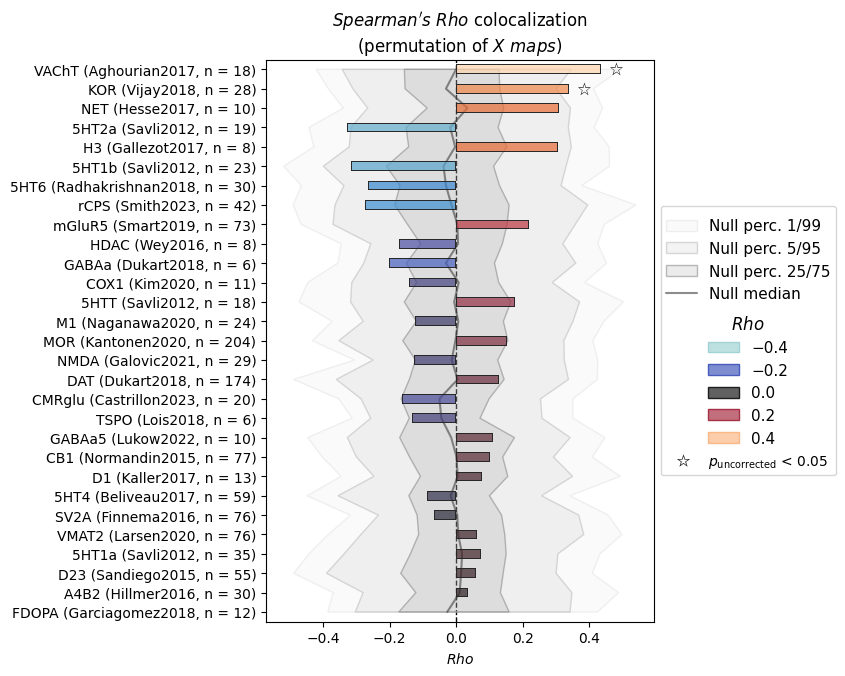

In [2]:
from nispace.workflows import simple_colocalization
from nispace.io import load_img

pain_map = load_img("neuroquery/pain.nii.gz")

nsp = simple_colocalization(
    y={"Pain": pain_map},  # dict key becomes the map label; can also be just the image
    x="pet",               # string shortcut: automatically fetches the PET reference dataset
    x_collection="UniqueTracers", # dataset collection to use for the PET reference dataset, optional
    parcellation="Schaefer200", # parcellation to use for the analysis
    colocalization_method="spearman", # colocalization method, default is "spearman"
    permute_kwargs={"p_tails": "upper"},  # directional test
    mc_method="meff", # multiple comparison correction method, default is "meff" (effective number of tests)
    n_perm=1000, # number of null runs, increase to >=10000 for final analyses
    seed=42, # random seed for reproducibility
    n_proc=4, # number of processes to use for parallelization, default is 1; set to -1 to use all available cores
    return_nispace_only=True # return only the NiSpace object, will be default in future versions
)

In [3]:
colocs   = nsp.get_colocalizations()
p_values = nsp.get_p_values()
q_values = nsp.get_p_values(mc_method="meff")

results = pd.concat([colocs, p_values, q_values], keys=["rho", "p", "q"])
results.droplevel(1).T.sort_values(by="p").head(8)

,,rho,p,q
set,map,,,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.435971,0.020,0.219690
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.339014,0.031,0.320682
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.309315,0.068,0.578821
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.304823,0.075,0.616060
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.219451,0.167,0.893923
Serotonin,target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012,0.176491,0.227,0.957637
Opioids/Endocannabinoids,target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020,0.151909,0.254,0.972622
Dopamine,target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018,0.129229,0.272,0.979716


INFO | 01/06/26 12:43:35 | nispace.plotting: Significance annotation: 2/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


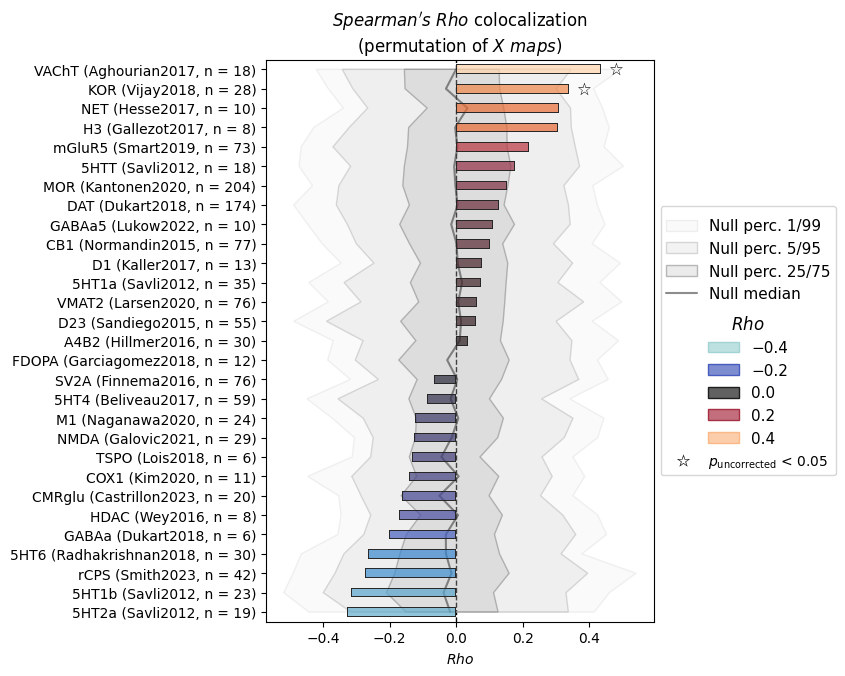

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x30f1fa490>)

In [4]:
# the nsp_object is a fully fitted NiSpace object — you can use all methods on it
nsp.plot(sort_by="coloc")

## `group_comparison()` — patient vs. control

The group comparison workflow handles the full pipeline for individual subject data: covariate regression, effect size computation, colocalization, and group label permutation.

The `design` argument is a DataFrame with one row per subject. The column `"groups"` is required; any other columns are treated as covariates to regress out. A `"site"` column triggers ComBat harmonization if `combat=True`.

We use the anorexia nervosa example dataset here.

> **Note:** This dataset is **simulated** and not intended for scientific use — it exists purely for demonstration purposes.

INFO | 01/06/26 12:43:35 | nispace.datasets: Loading example dataset: 'anorexianervosa', parcellated with: Schaefer200Parcels7Networks.


INFO | 01/06/26 12:43:35 | nispace.workflows: Loading integrated pet dataset as X data.


INFO | 01/06/26 12:43:35 | nispace.datasets: Loading pet maps.


INFO | 01/06/26 12:43:35 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 01/06/26 12:43:35 | nispace.datasets: Filtering maps by collection.


...

WARNING | 01/06/26 12:43:35 | nispace.io: Parcellated data contains nan values!


INFO | 01/06/26 12:43:35 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


INFO | 01/06/26 12:43:35 | nispace.workflows: DataFrame provided for design. Expecting 'groups' and, if paired==True, 'subjects' columns.


INFO | 01/06/26 12:43:35 | nispace.workflows: Design matrix of shape (100, 3). Assuming 100 subjects/maps.


INFO | 01/06/26 12:43:35 | nispace.core.clean_y: Detected categorical covariates: none; continuous: ['age', 'sex'].


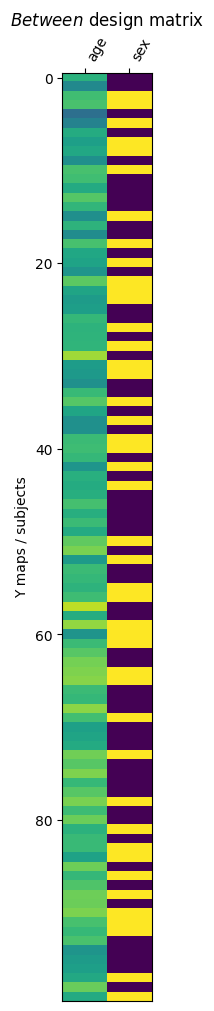

INFO | 01/06/26 12:43:35 | nispace.core.clean_y: Protecting 1 variable(s) during regression: ['groups_HC'].


INFO | 01/06/26 12:43:35 | nispace.core.clean_y: Regressing 2 between covariate(s) from Y.


Regressing 2 between covariate(s) from Y, protecting 1 variable(s) (4 proc):   0%|                     | 0/200 [00:00<?, ?it/s]

Regressing 2 between covariate(s) from Y, protecting 1 variable(s) (4 proc):   4%|▌            | 8/200 [00:02<00:51,  3.76it/s]

Regressing 2 between covariate(s) from Y, protecting 1 variable(s) (4 proc): 100%|███████████| 200/200 [00:02<00:00, 91.75it/s]

...

Processing null arrays (4 proc): 100%|███████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2132.27it/s]

Null colocalizations (spearman, 4 proc):   0%|                                                        | 0/1000 [00:00<?, ?it/s]

Null colocalizations (spearman, 4 proc): 100%|██████████████████████████████████████████| 1000/1000 [00:00<00:00, 13356.08it/s]

INFO | 01/06/26 12:43:39 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


INFO | 01/06/26 12:43:39 | nispace.plotting: Significance annotation: 9/29 p_uncorrected < 0.05, 5/29 p_meffgalwey < 0.05


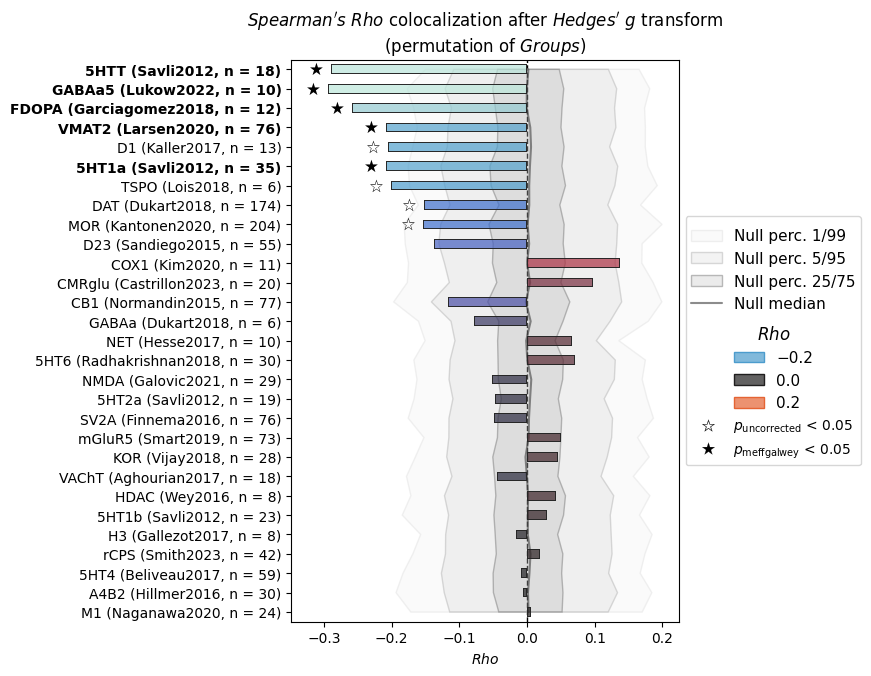

In [5]:
from nispace.workflows import group_comparison
from nispace.datasets import fetch_example

# load the anorexia nervosa example data
an_data = fetch_example("anorexianervosa", parcellation="Schaefer200")

# extract group labels
groups = an_data.index.str.extract(r'(AN|HC)$')[0].values

# generate synthetic covariates
rng = np.random.default_rng(42)
age = np.concatenate([rng.normal(25, 5, 50), rng.normal(30, 5, 50)])
sex = rng.integers(0, 2, 100)

# design matrix: groups column is mandatory, others are covariates
design = pd.DataFrame({
    "groups": groups,
    "age": age,
    "sex": sex
}, index=an_data.index)

nsp_gc = group_comparison(
    y=an_data,
    design=design,
    x="pet",
    x_collection="UniqueTracers",
    parcellation="Schaefer200",
    comparison_method="hedges(a,b)",
    colocalization_method="spearman",
    n_perm=1000,
    seed=42,
    n_proc=4,
    return_nispace_only=True
)

In [6]:
colocs_gc = nsp_gc.get_colocalizations()
p_gc      = nsp_gc.get_p_values()
q_gc      = nsp_gc.get_corrected_p_values() # short cut for get_p_values(mc_method="meff")

gc_results = pd.concat([colocs_gc, p_gc, q_gc], keys=["rho", "p", "q"])
gc_results.droplevel(1).T.sort_values(by="p").head(8)

rho      p  \
set       map                                                                   
Serotonin target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   -0.289860  0.001   
GABA      target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu... -0.294028  0.001   
Dopamine  target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g... -0.258163  0.001   
Serotonin target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa... -0.208632  0.004   
General   target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020 -0.208262  0.004   
Immunity  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018    -0.200293  0.008   
Dopamine  target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller... -0.204952  0.008   
          target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018 -0.152391  0.026   

                                                                     q  
set       map                                                           
Serotonin target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012    0.012210  
GABA      target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu...  0.012210  
Dopamine  target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g...  0.012210  
Serotonin target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa...  0.048022  
General   target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020  0.048022  
Immunity  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018     0.093917  
Dopamine  target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller...  0.093917  
          target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018  0.276367

INFO | 01/06/26 12:43:39 | nispace.plotting: Significance annotation: 9/29 p_uncorrected < 0.05, 5/29 p_meffgalwey < 0.05


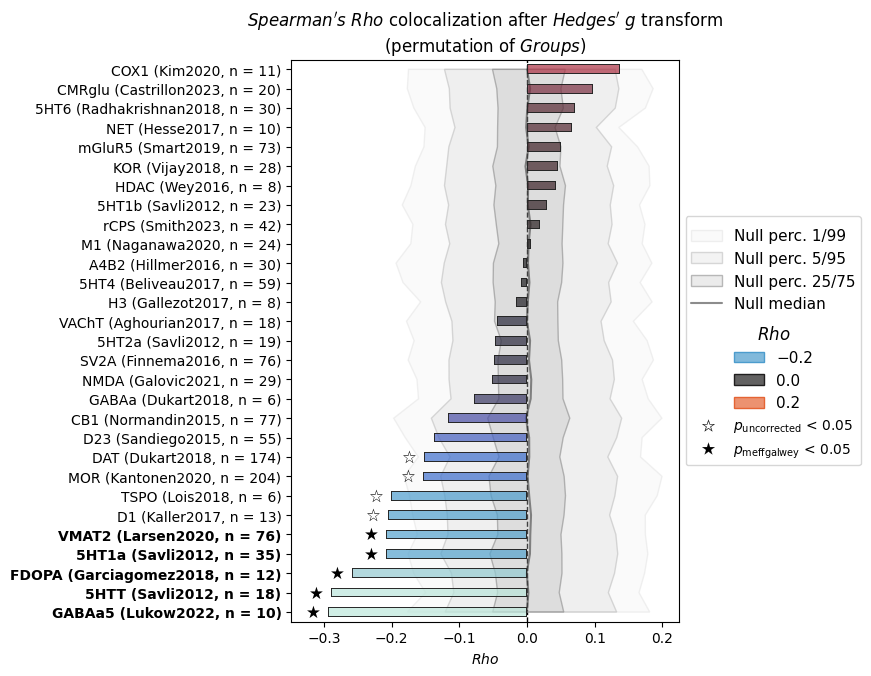

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization after $Hedges'\\ g$ transform\n(permutation of $Groups$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x319cfafa0>)

In [7]:
nsp_gc.plot(sort_by="coloc")

WARNING | 01/06/26 12:43:39 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 01/06/26 12:43:39 | nispace.plotting: brainplot: threshold='auto' → 0.001035715569742024


INFO | 01/06/26 12:43:39 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.


INFO | 01/06/26 12:43:40 | nispace.core.parcellation: Parcellation 'Schaefer200Parcels7Networks': active space set to 'MNI152NLin2009cAsym' (was 'fsLR').


INFO | 01/06/26 12:43:40 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


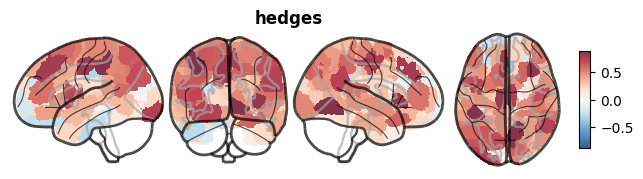

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [8]:
# effect size map on the brain
nsp_gc.plot_brain(data="Y", symmetric_cmap=True)

## `simple_xsea()` — X-Set Enrichment Analysis

XSEA tests whether the average colocalization between your input map and a *set* of reference maps is higher than expected by chance. This is useful when you have reference maps organized into biologically meaningful groups (e.g., gene expression grouped by cell type).

We'll cover XSEA in much more detail in [Notebook 10](intro10_xsea.ipynb). Here's a minimal example:

INFO | 01/06/26 12:43:43 | nispace.workflows: Loading integrated mrna dataset as X data.


INFO | 01/06/26 12:43:43 | nispace.datasets: Loading mrna maps.


INFO | 01/06/26 12:43:43 | nispace.datasets: Loading integrated collection 'CellTypesSilettiSuperclusters' for dataset 'mrna'.


INFO | 01/06/26 12:43:43 | nispace.datasets: Filtering maps by collection.


INFO | 01/06/26 12:43:44 | nispace.datasets: Loading data parcellated with 'Schaefer200Parcels7Networks'


...

Null colocalizations (spearman, 4 proc):  18%|████████                                    | 184/1000 [00:00<00:00, 1540.68it/s]

Null colocalizations (spearman, 4 proc):  50%|██████████████████████▏                     | 504/1000 [00:00<00:00, 1745.50it/s]

Null colocalizations (spearman, 4 proc): 100%|███████████████████████████████████████████| 1000/1000 [00:00<00:00, 2628.50it/s]

INFO | 01/06/26 12:43:45 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


INFO | 01/06/26 12:43:45 | nispace.plotting: Significance annotation: 2/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


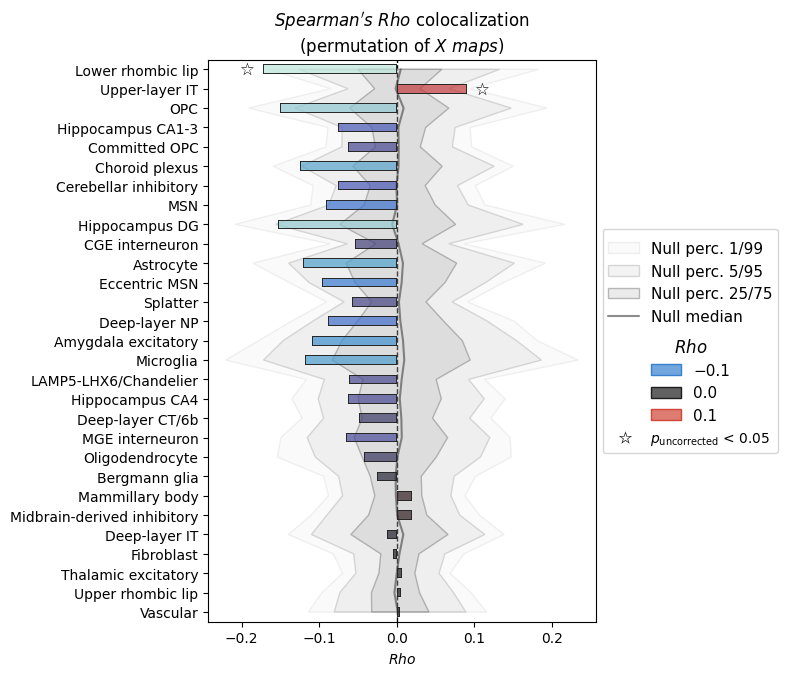

In [9]:
from nispace.workflows import simple_xsea
from nispace.datasets import fetch_reference

# use the anorexia nervosa Hedges' g map we computed above
hedges_g = nsp_gc.get_y()

# test against mRNA gene expression sets (cell type markers)
nsp_xsea = simple_xsea(
    y=hedges_g,
    x="mrna",          # mRNA gene expression reference
    x_collection="CellTypesSilettiSuperclusters",  # predefined cell type sets
    parcellation="Schaefer200",
    colocalization_method="spearman",
    n_perm=1000,
    seed=42,
    n_proc=4,
    return_nispace_only=True
)

INFO | 01/06/26 12:43:46 | nispace.plotting: Significance annotation: 2/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


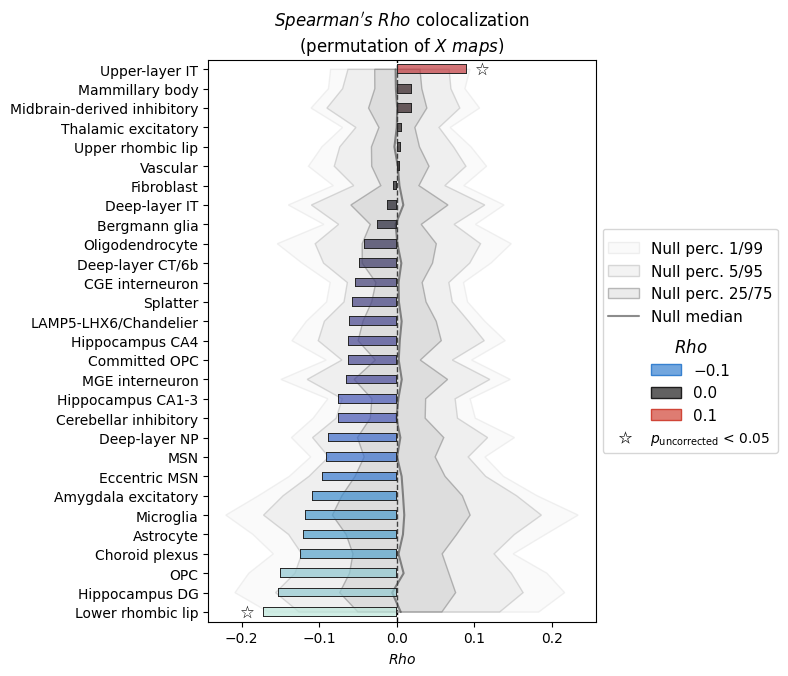

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x327ff0700>)

In [10]:
nsp_xsea.plot(sort_by="coloc")

## When to use workflows vs. the object API

| Situation | Recommended approach |
|-----------|---------------------|
| Quick analysis, standard pipeline | Workflow function |
| Need full control over each step | Object API (`NiSpace` class) |
| Custom preprocessing sequence | Object API |
| Running the same analysis on many maps | Object API (reuse the fitted object) |
| Embedding in a larger pipeline | Object API |
| Teaching/demonstration | Workflow (less boilerplate) |

The two approaches are not exclusive. You can start with a workflow, inspect the returned `nsp_object`, and then call additional methods on it — for example to plot with different settings, or to run additional permutation tests.

## Summary

All three workflows return a fitted `NiSpace` object (pass `return_nispace_only=True`). Retrieve results with `get_*` methods:

```python
nsp = simple_colocalization(y, x="pet", x_collection=None, parcellation="Schaefer200",
                             colocalization_method="spearman", mc_method="meff",
                             n_perm=10000, seed=None, n_proc=1,
                             return_nispace_only=True)

nsp = group_comparison(y, design, x="pet", comparison_method="hedges(a,b)",
                       colocalization_method="spearman", mc_method="meff",
                       n_perm=10000, seed=None, n_proc=1,
                       return_nispace_only=True)

nsp = simple_xsea(y, x="mrna", x_collection=None, parcellation="Schaefer200",
                  colocalization_method="spearman", mc_method="meff",
                  n_perm=10000, seed=None, n_proc=1,
                  return_nispace_only=True)

# retrieve results
colocs   = nsp.get_colocalizations()
p_values = nsp.get_p_values()
q_values = nsp.get_p_values(mc_method="meff")
```

Next: [Notebook 10](intro10_xsea.ipynb) dives deep into X-Set Enrichment Analysis.